# Comparison of Classical Machine Learning and Artificial Neural Networks

This notebook summarizes and compares the final results obtained from the four predictive modeling pipelines developed in this project:

1. Classical Machine Learning – Classification
2. Artificial Neural Network – Classification
3. Classical Machine Learning – Regression
4. Artificial Neural Network – Regression

The goal is not to develop a single universal model, but rather to evaluate how different learning paradigms perform on different predictive tasks within the healthcare domain.

Classification experiments were conducted using the Heart Disease dataset, while regression experiments were conducted using the Medical Cost Personal dataset.

### 1) Import libraries

In [8]:
#----- Tools, visualizers -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from comparison_results import *


### 2) Classification Comparison

In [9]:
cls_compr_df = pd.DataFrame(classification_results)
cls_compr_df

,Stacking,ANN
Accuracy,0.9000,0.8800
F1,0.8982,0.8839
FN,5.0000,7.0000
FP,9.0000,9.0000
Threshold,0.4000,0.5000


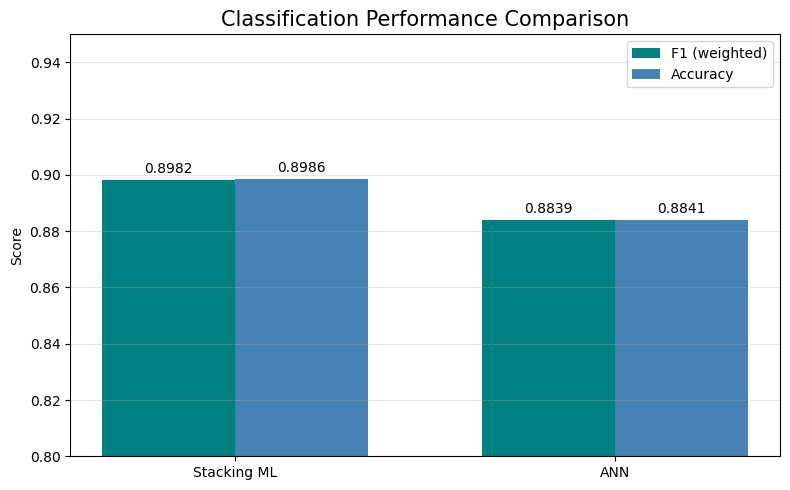

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Stacking ML', 'ANN']
f1_scores = [0.8982, 0.8839]
accuracy = [0.8986, 0.8841]   # approximate from reports

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    f1_scores,
    width,
    label='F1 (weighted)',
    color='teal'
)

bars2 = ax.bar(
    x + width/2,
    accuracy,
    width,
    label='Accuracy',
    color='steelblue'
)

ax.set_title(
    'Classification Performance Comparison',
    fontsize=15
)

ax.set_ylabel('Score')
ax.set_ylim(0.80, 0.95)
ax.grid(axis='y', alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f'{h:.4f}',
            (bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center'
        )

plt.tight_layout()
plt.show()

### Classification Results (Test Set)

| Model | Accuracy | F1 (Weighted) | Precision | Recall | FN | FP | Threshold |
|---------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|
| Stacking Classifier (ML) | 0.90 | 0.8982 | 0.89 | 0.93 | 5 | 9 | 0.40 |
| ANN Classifier | 0.88 | 0.8839 | 0.88 | 0.91 | 7 | 9 | 0.50 |

### Discussion

Both approaches achieved strong predictive performance on the heart disease classification task.

The Stacking Classifier achieved the highest weighted F1 score (0.8982) and reduced the number of false negatives from 7 to 5 compared with the ANN model. Since false negatives correspond to missed disease cases, this improvement is clinically meaningful.

The ANN classifier produced competitive results (F1 = 0.8839) despite using a relatively simple architecture consisting of two hidden layers and dropout regularization.

Overall, ensemble learning provided the strongest classification performance, although the ANN remained highly competitive.

### 3) Clinical Error Comparison

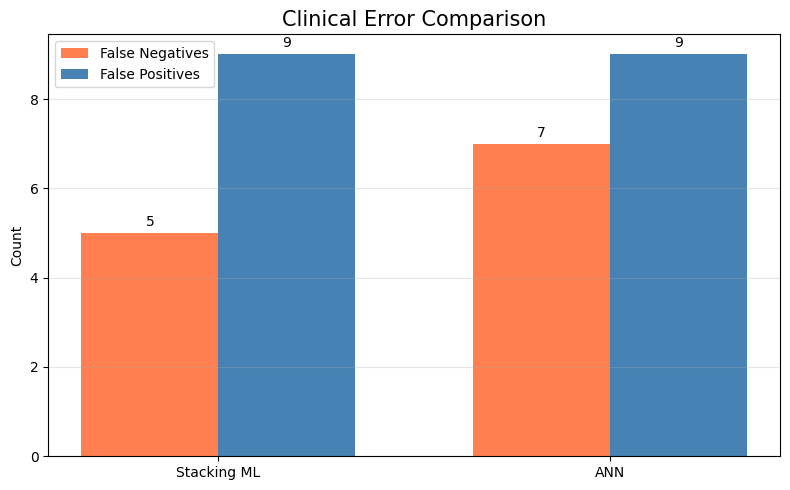

In [12]:
fig, ax = plt.subplots(figsize=(8,5))

models = ['Stacking ML', 'ANN']

fn = [5, 7]
fp = [9, 9]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    fn,
    width,
    label='False Negatives',
    color='coral'
)

bars2 = ax.bar(
    x + width/2,
    fp,
    width,
    label='False Positives',
    color='steelblue'
)

ax.set_title(
    'Clinical Error Comparison',
    fontsize=15
)

ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f'{int(h)}',
            (bar.get_x()+bar.get_width()/2, h),
            xytext=(0,5),
            textcoords='offset points',
            ha='center'
        )

plt.tight_layout()
plt.show()

### 4) Regression Comparison

In [13]:
reg_compr_df = pd.DataFrame(regression_results)
reg_compr_df

,Ridge,ANN
R2,0.8825,0.8425
MAE,2298.7300,2278.5500
RMSE,4230.3400,4897.5600


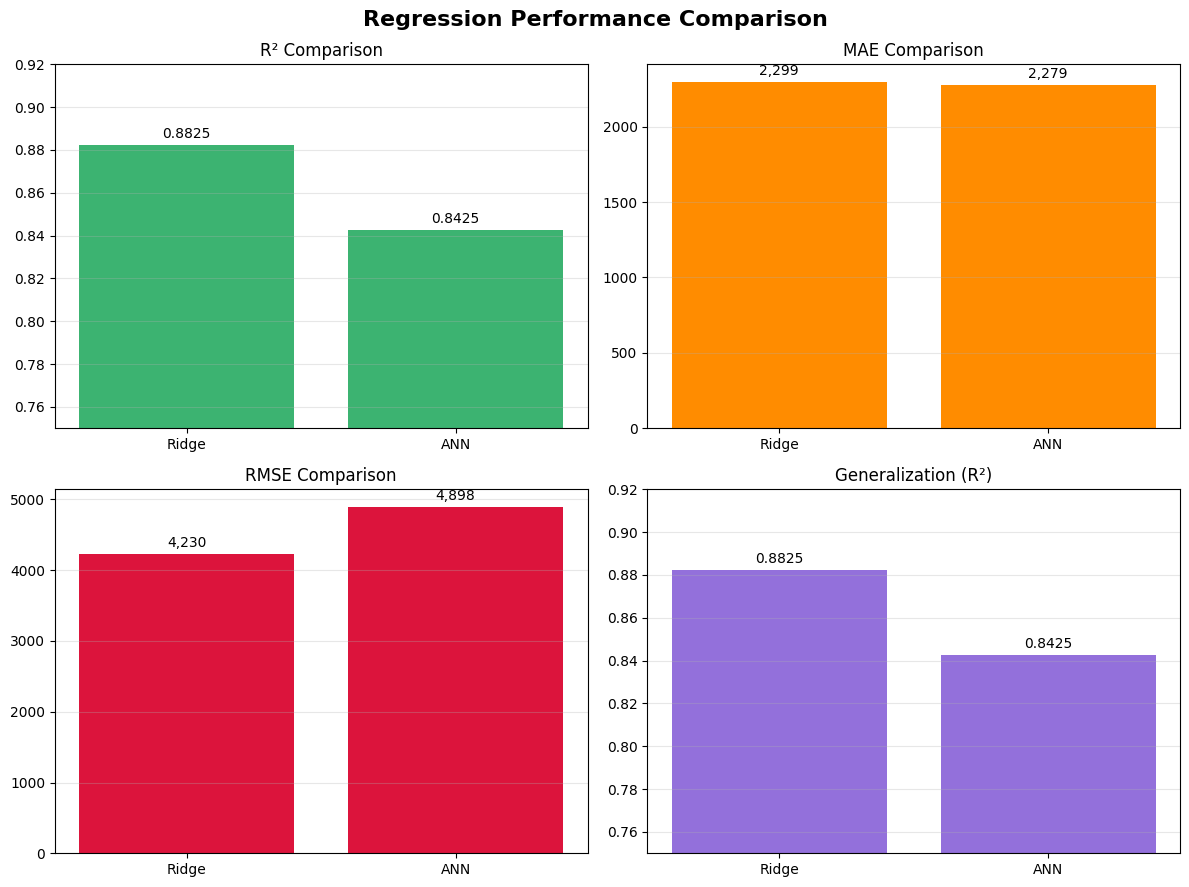

In [16]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2,
    figsize=(12,9)
)

models = ['Ridge', 'ANN']

r2 = [0.8825, 0.8425]
mae = [2298.73, 2278.55]
rmse = [4230.34, 4897.56]

# ---------------- R²

bars = ax1.bar(
    models,
    r2,
    color='mediumseagreen'
)

ax1.set_title('R² Comparison')
ax1.set_ylim(0.75, 0.92)
ax1.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax1.annotate(
        f'{h:.4f}',
        (b.get_x()+b.get_width()/2, h),
        xytext=(0,5),
        textcoords='offset points',
        ha='center'
    )

# ---------------- MAE

bars = ax2.bar(
    models,
    mae,
    color='darkorange'
)

ax2.set_title('MAE Comparison')
ax2.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax2.annotate(
        f'{h:,.0f}',
        (b.get_x()+b.get_width()/2, h),
        xytext=(0,5),
        textcoords='offset points',
        ha='center'
    )

# ---------------- RMSE

bars = ax3.bar(
    models,
    rmse,
    color='crimson'
)

ax3.set_title('RMSE Comparison')
ax3.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax3.annotate(
        f'{h:,.0f}',
        (b.get_x()+b.get_width()/2, h),
        xytext=(0,5),
        textcoords='offset points',
        ha='center'
    )

# ---------------- Combined score

combined = [0.8825, 0.8425]

bars = ax4.bar(
    models,
    combined,
    color='mediumpurple'
)

ax4.set_title('Generalization (R²)')
ax4.set_ylim(0.75, 0.92)
ax4.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    ax4.annotate(
        f'{h:.4f}',
        (b.get_x()+b.get_width()/2, h),
        xytext=(0,5),
        textcoords='offset points',
        ha='center'
    )

plt.suptitle(
    'Regression Performance Comparison',
    fontsize=16,
    weight='bold'
)

plt.tight_layout()
plt.show()

### Regression Results (Test Set)

| Model | R² | MAE ($) | RMSE ($) |
|---------|---------:|---------:|---------:|
| Ridge Regression | 0.8825 | 2298.73 | 4230.34 |
| ANN Regression | 0.8425 | 2278.55 | 4897.56 |

### Discussion

For medical cost prediction, both models achieved strong predictive performance.

Ridge Regression achieved the highest coefficient of determination (R² = 0.8825), indicating superior overall explanatory power. The ANN achieved a slightly lower R² value (0.8425) but produced a marginally lower MAE.

The results suggest that the relationship between the available predictors and medical expenses is sufficiently structured that a regularized linear model can capture most of the predictive signal. Increasing model complexity through neural networks did not provide additional gains on this dataset.

Consequently, Ridge Regression was selected as the best-performing regression model.

### 5) ANN Regression Evolution

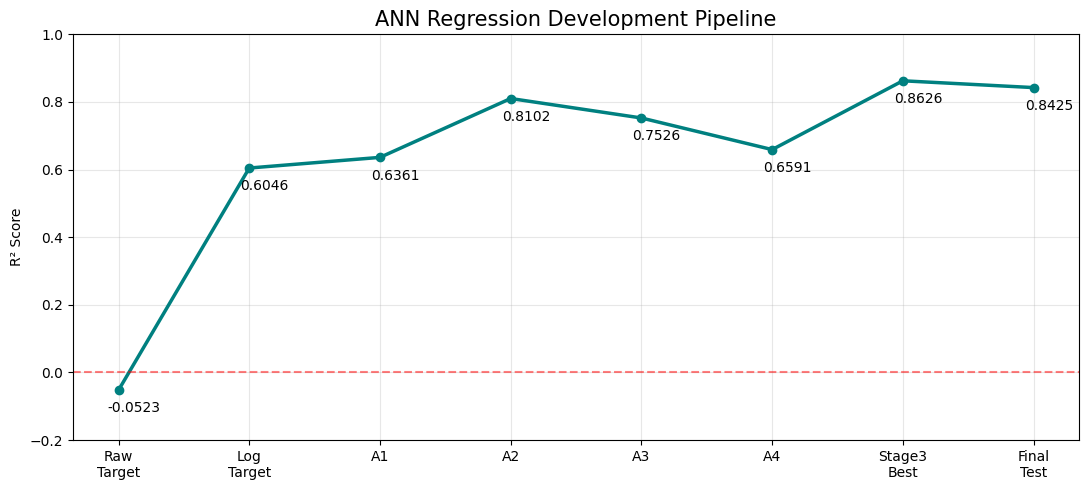

In [27]:
stages = [
    'Raw\nTarget',
    'Log\nTarget',
    'A1',
    'A2',
    'A3',
    'A4',
    'Stage3\nBest',
    'Final\nTest'
]

r2_scores = [
    -0.0523,
    0.6046,
    0.6361,
    0.8102,
    0.7526,
    0.6591,
    0.8626,
    0.8425
]

fig, ax = plt.subplots(figsize=(11,5))

ax.plot(
    stages,
    r2_scores,
    marker='o',
    linewidth=2.5,
    color='teal'
)

ax.set_title(
    'ANN Regression Development Pipeline',
    fontsize=15
)

ax.set_ylabel('R² Score')
ax.grid(alpha=0.3)

for x, y in zip(stages, r2_scores):
    ax.annotate(
        f'{y:.4f}',
        (x, y),
        xytext=(11,-16),
        textcoords='offset points',
        ha='center'
    )

ax.axhline(
    y=0,
    linestyle='--',
    alpha=0.5,
    color='red'
)

ax.set_ylim(-0.2, 1.0)
plt.tight_layout()
plt.show()

### ANN Regression Development Summary

| Stage | Configuration | R² |
|---------|---------|---------:|
| Stage 1 | Raw Target + Architecture A | -0.0523 |
| Stage 1 | Log Target + Architecture A | 0.6046 |
| Stage 2 | Architecture A1 (64-32) | 0.6361 |
| Stage 2 | Architecture A2 (128-64) | 0.8102 |
| Stage 2 | Architecture A3 (128-64-32) | 0.7526 |
| Stage 2 | Architecture A4 (128-64-32-16) | 0.6591 |
| Stage 3 | Dropout=0.1, Epochs=40 | 0.8626 |
| Stage 3 | Dropout=0.1, Epochs=40, Batch=48 | 0.8518 |
| Stage 3 | Dropout=0.05, Epochs=40, Batch=48 | 0.8551 |
| Final Test | Selected ANN Model | 0.8425 |

### Discussion

The ANN regression pipeline underwent a structured three-stage benchmarking process.

The most important improvement came from applying a logarithmic transformation to the target variable. Without transformation, the network failed to learn effectively and produced negative R² values. After transformation, predictive performance increased substantially.

Architecture benchmarking showed that a moderate-sized architecture (128-64) outperformed both smaller and deeper networks. Further refinement through dropout and training configuration adjustments yielded validation R² values exceeding 0.86.

The final model generalized well to the unseen test set (R² = 0.8425), indicating that the architecture did not suffer from significant overfitting.

### 6) Ridge Regression Evolution

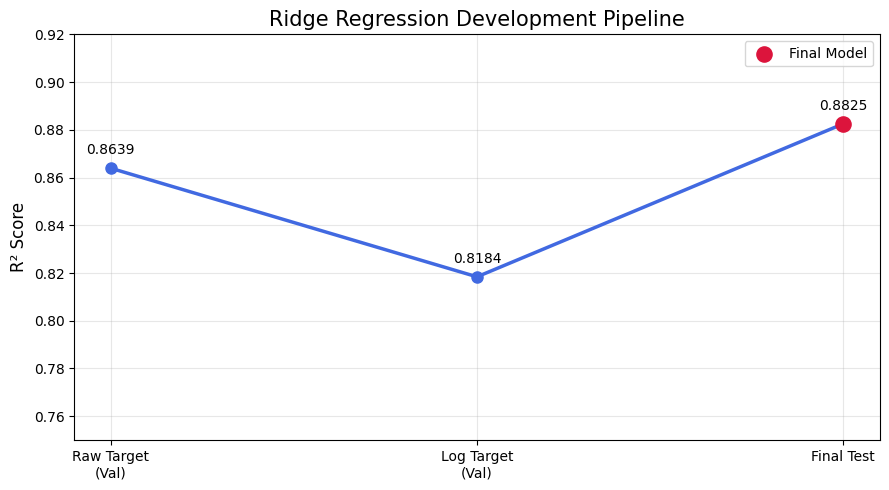

In [ ]:

ridge_stages = [
    "Raw Target\n(Val)",
    "Log Target\n(Val)",
    "Final Test"
]

ridge_r2 = [
    0.8639,
    0.8184,
    0.8825
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    ridge_stages,
    ridge_r2,
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='royalblue'
)

ax.set_title(
    'Ridge Regression Development Pipeline',
    fontsize=15
)

ax.set_ylabel('R² Score', fontsize=12)
ax.set_ylim(0.75, 0.92)
ax.grid(alpha=0.3)

# Annotate points
for x, y in zip(ridge_stages, ridge_r2):
    ax.annotate(
        f'{y:.4f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center'
    )

# Highlight final result
ax.scatter(
    ridge_stages[-1],
    ridge_r2[-1],
    s=120,
    color='crimson',
    zorder=5,
    label='Final Model'
)

ax.legend()
plt.tight_layout()
plt.show()

# Key Findings

### Classification

✓ Stacking Classifier achieved the best overall classification performance.

✓ ANN Classification achieved competitive results with a simpler modeling framework.

✓ Threshold optimization reduced false negatives while maintaining strong F1 scores.

---

### Regression

✓ Ridge Regression achieved the highest test-set R² score.

✓ ANN Regression benefited dramatically from target logarithmic transformation.

✓ Moderate network depth performed better than deeper architectures.

✓ Classical machine learning ultimately outperformed ANN on the medical cost prediction task.

---

### General Observations

✓ Ensemble methods were particularly effective for classification tasks.

✓ Regularized linear models remained highly competitive for structured tabular regression problems.

✓ Neural networks required more extensive architecture selection and preprocessing to reach comparable performance.

✓ Model complexity alone did not guarantee superior predictive performance.

# Final Conclusion

This project demonstrated the application of both classical machine learning and deep learning approaches to healthcare-related classification and regression problems.

For classification, ensemble learning produced the strongest results, with the Stacking Classifier achieving the highest weighted F1 score and the lowest number of missed disease cases.

For regression, Ridge Regression achieved the highest predictive performance and outperformed the Artificial Neural Network on the held-out test set.

The findings suggest that for structured tabular healthcare datasets, carefully designed classical machine learning pipelines remain highly competitive and can outperform more complex neural network architectures. Nevertheless, neural networks demonstrated strong performance after appropriate preprocessing, architecture selection, and regularization.

Overall, the project highlights the importance of systematic experimentation, preprocessing design, model benchmarking, threshold optimization, and rigorous evaluation when developing predictive models for healthcare applications.